<a href="https://colab.research.google.com/github/HARISHLOKESH/SPOTIFY-MUSIC-CLUSTERING/blob/main/PROJECTSPOTIFY_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")

print("Path to dataset files:", path)

100%|██████████| 15.5M/15.5M [00:01<00:00, 9.10MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zaheenhamidani/ultimate-spotify-tracks-db/versions/3


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [28]:
df = pd.read_csv(path + "/SpotifyFeatures.csv")

In [29]:
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [30]:
df.shape

(232725, 18)

In [31]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [34]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [35]:
df.isnull().sum()

,0
genre,0
artist_name,0
track_name,1
track_id,0
popularity,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0


In [36]:
df = df.dropna()

In [37]:
features = df[['danceability','energy','tempo','loudness','valence']]

In [38]:
features.shape

(232724, 5)

In [39]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [40]:
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

In [41]:
scaled_df.head()

,danceability,energy,tempo,loudness,valence
0,-0.890943,1.286904,1.595608,1.290703,1.380742
1,0.191988,0.630246,1.823254,0.668683,1.388432
2,0.585291,-1.669953,-0.588322,-0.718399,-0.334220
3,-1.693713,-0.929790,1.750598,-0.434814,-0.876394
4,-1.203431,-1.313156,0.741435,-1.930596,-0.249626


In [42]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

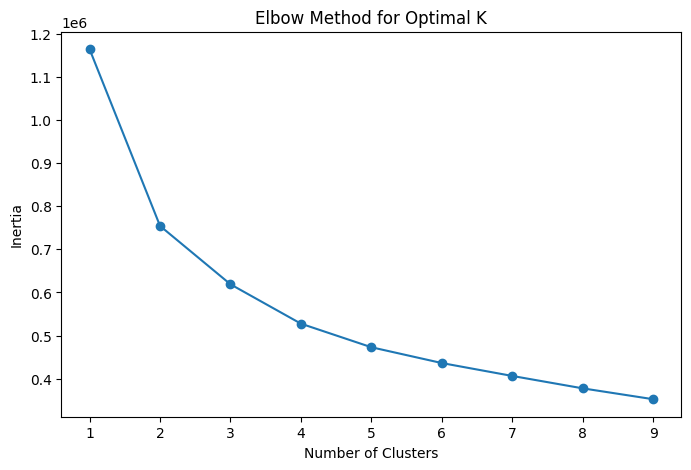

In [43]:
plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [44]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_df)

In [45]:
df['cluster'].value_counts()

,count
cluster,
2,61613
4,49372
1,48377
0,44524
3,28838


In [46]:
cluster_summary = df.groupby('cluster')[features.columns].mean()

print(cluster_summary)

         danceability    energy       tempo   loudness   valence
cluster                                                         
0            0.501834  0.746107  160.425566  -6.206252  0.502990
1            0.549402  0.757912  100.653647  -6.220940  0.378024
2            0.728033  0.665085  112.284525  -7.339320  0.734174
3            0.265519  0.133773   99.043214 -21.383675  0.132681
4            0.558591  0.367716  113.370194 -11.767943  0.326637


In [47]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2'])

pca_df['cluster'] = df['cluster']

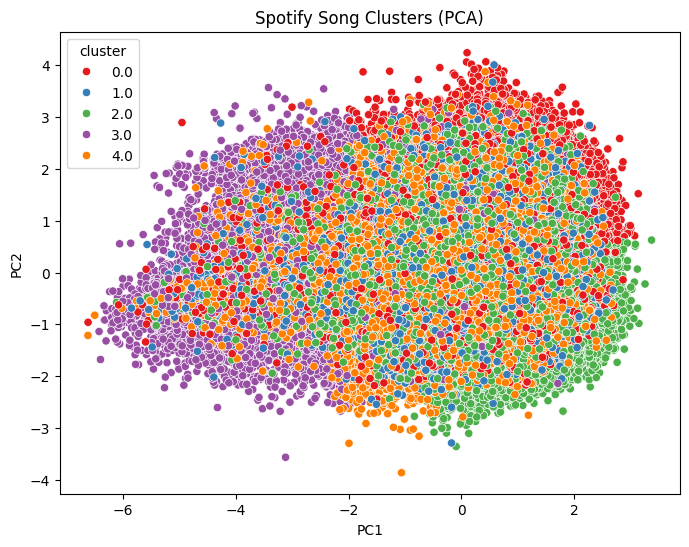

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    data=pca_df
)

plt.title("Spotify Song Clusters (PCA)")
plt.show()

In [49]:
tsne = TSNE(n_components=2, random_state=42)

tsne_result = tsne.fit_transform(scaled_df.sample(5000))

In [50]:
tsne_df = pd.DataFrame(tsne_result, columns=['TSNE1','TSNE2'])

tsne_df['cluster'] = df['cluster'].sample(5000).values

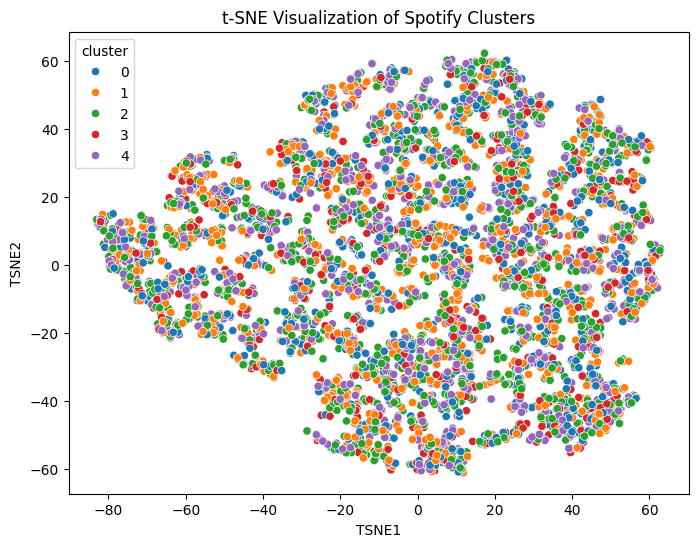

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    hue='cluster',
    palette='tab10',
    data=tsne_df
)

plt.title("t-SNE Visualization of Spotify Clusters")
plt.show()